In [253]:
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder


In [254]:
df=pd.read_csv("data.csv")

In [255]:
df.head()


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [256]:
df['Date'] = pd.to_datetime(df['Date'])

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                3322 non-null   datetime64[ns]
 1   Symbol              3322 non-null   object        
 2   Series              3322 non-null   object        
 3   Prev Close          3322 non-null   float64       
 4   Open                3322 non-null   float64       
 5   High                3322 non-null   float64       
 6   Low                 3322 non-null   float64       
 7   Last                3322 non-null   float64       
 8   Close               3322 non-null   float64       
 9   VWAP                3322 non-null   float64       
 10  Volume              3322 non-null   int64         
 11  Turnover            3322 non-null   float64       
 12  Trades              2456 non-null   float64       
 13  Deliverable Volume  3322 non-null   int64       

In [258]:
df['Trades']=df['Trades'].fillna(df['Trades'].median)
df['Trades'].isnull().sum()


0

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                3322 non-null   datetime64[ns]
 1   Symbol              3322 non-null   object        
 2   Series              3322 non-null   object        
 3   Prev Close          3322 non-null   float64       
 4   Open                3322 non-null   float64       
 5   High                3322 non-null   float64       
 6   Low                 3322 non-null   float64       
 7   Last                3322 non-null   float64       
 8   Close               3322 non-null   float64       
 9   VWAP                3322 non-null   float64       
 10  Volume              3322 non-null   int64         
 11  Turnover            3322 non-null   float64       
 12  Trades              3322 non-null   object        
 13  Deliverable Volume  3322 non-null   int64       

In [260]:
df['next_day_open'] = df['Open'].shift(-1)

In [261]:
df = df.dropna().reset_index(drop=True)

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321 entries, 0 to 3320
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                3321 non-null   datetime64[ns]
 1   Symbol              3321 non-null   object        
 2   Series              3321 non-null   object        
 3   Prev Close          3321 non-null   float64       
 4   Open                3321 non-null   float64       
 5   High                3321 non-null   float64       
 6   Low                 3321 non-null   float64       
 7   Last                3321 non-null   float64       
 8   Close               3321 non-null   float64       
 9   VWAP                3321 non-null   float64       
 10  Volume              3321 non-null   int64         
 11  Turnover            3321 non-null   float64       
 12  Trades              3321 non-null   object        
 13  Deliverable Volume  3321 non-null   int64       

In [263]:
# Example: drop categorical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
X = df[numerical_features].drop('next_day_open', axis=1)  # all numerical except target
y = df['next_day_open'].values.reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (3321, 11)
y shape: (3321, 1)


In [264]:

df['next_day_open'] = df['Open'].shift(-1)
df = df.dropna().reset_index(drop=True)

In [265]:
x_train,x_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (2656, 11)
x_test: (665, 11)
y_train: (2656, 1)
y_test: (665, 1)


In [266]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

y_train_scaled= scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)


In [267]:
X_train = torch.tensor(x_train_scaled, dtype=torch.float32)
X_test  = torch.tensor(x_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test  = torch.tensor(y_test_scaled, dtype=torch.float32)

In [268]:
class ANNRegression(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.layer1 = nn.Linear(input_features, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

model = ANNRegression(X_train.shape[1])
print(model)

ANNRegression(
  (layer1): Linear(in_features=11, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


In [269]:
# -----------------------------------------
# STEP 6: LOSS FUNCTION & OPTIMIZER
# -----------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [270]:


# -----------------------------------------
# STEP 7: TRAINING LOOP
# -----------------------------------------
epochs = 200

for epoch in range(epochs):
    # Forward pass
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print progress
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# -----------------------------------------

Epoch [20/200], Loss: 0.1249
Epoch [40/200], Loss: 0.0176
Epoch [60/200], Loss: 0.0049
Epoch [80/200], Loss: 0.0039
Epoch [100/200], Loss: 0.0033
Epoch [120/200], Loss: 0.0030
Epoch [140/200], Loss: 0.0028
Epoch [160/200], Loss: 0.0026
Epoch [180/200], Loss: 0.0025
Epoch [200/200], Loss: 0.0024


In [271]:
# STEP 8: MODEL EVALUATION
# -----------------------------------------
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

# Inverse scaling to original values
y_pred_final = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_final = scaler_y.inverse_transform(y_test.numpy())

print("\nFirst 10 Predictions vs Actual:")
for i in range(10):
    print(f"Predicted: {y_pred_final[i][0]:.2f}, Actual: {y_test_final[i][0]:.2f}")


First 10 Predictions vs Actual:
Predicted: 145.48, Actual: 141.05
Predicted: 134.28, Actual: 126.00
Predicted: 377.47, Actual: 379.70
Predicted: 133.68, Actual: 131.45
Predicted: 152.40, Actual: 152.80
Predicted: 369.25, Actual: 368.80
Predicted: 375.69, Actual: 385.00
Predicted: 178.29, Actual: 171.60
Predicted: 354.02, Actual: 352.95
Predicted: 247.07, Actual: 239.00


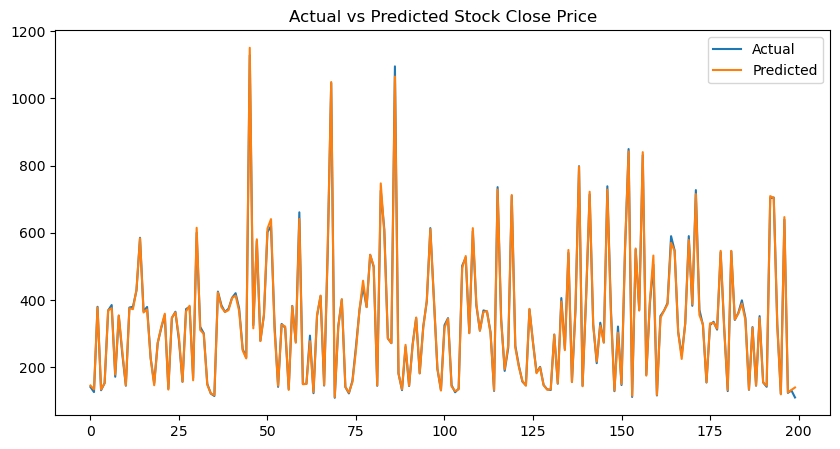

In [274]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test_final[:200], label='Actual')
plt.plot(y_pred_final[:200], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Stock Close Price')
plt.show()